# 02 · Does the offer work better for some segments? — segment effects (pathmc)

**The business decision.** The email lifts spend *on average* (that's the ATE — Average Treatment Effect — from notebook 01). But
an average can hide everything that matters: maybe the email really moves **high-value, highly-engaged**
customers and barely touches the rest. If the segments genuinely differ, we should write
segment-specific send rules; if the apparent "gap" is just noise, chasing it would be overfitting our
marketing to randomness. Either way we want to know **what it costs to treat everyone as the average**.

### The concept: moderation and the CATE

When a treatment's effect *depends on who receives it*, we say the effect is **moderated** by the
customer's characteristics, and the characteristic (here, being high-value, or an engagement score) is a
**moderator**. Formally we're estimating the **CATE** — the *Conditional* Average Treatment Effect,
$\tau(x) = \mathbb{E}[Y(1)-Y(0)\mid X = x]$: the average email effect *among customers who look like $x$*.
($Y(1), Y(0)$ are the two potential outcomes — spend if emailed / not — from notebook 01; $\mathbb{E}[\cdot]$
is "average over customers.") The ATE is just the CATE averaged over everybody.

### The tool: a structural model + the do-operator

Notebook 01 used flexible trees (BART) to get the CATE. Here we use a different, more *interpretable*
approach — a **structural causal model** via the `pathmc` library. We write down the equation we believe
generated spend (including an **interaction term** — a feature that multiplies the treatment, which is
exactly how "the effect depends on a moderator" is encoded), fit it, and then ask the model counterfactual
questions with the **do-operator**: `do(email=1)` means "*intervene* to email this customer," as opposed
to merely *observing* emailed customers (who differ in other ways). The difference in predicted spend
between `do(email=1)` and `do(email=0)`, at a given $x$, *is* the CATE at $x$.

The single most important output is the **posterior of the interaction coefficient** (the **posterior** is the distribution of plausible values for a quantity after the data have spoken — wide when we're unsure, tight when we're sure; every "is it real?" question below is read off it): if it's clearly
away from zero, the segments *really* respond differently; if it straddles zero, we can't tell the gap from noise — so we shouldn't build segment rules on it (and might instead run a bigger test). That's the "is the difference real?" test, answered with uncertainty.

### How this notebook is organised

The repo's fixed **7-step contract** — 1 question · 2 simulate a known truth · 3 identify · 4 estimate ·
5 validate · 6 decide in € · 7 caveats — plus the depth a skeptic will ask for at each step:

- **Step 3** draws the DAG and walks the three identification assumptions one by one;
- **Step 4** puts the likelihood *and* the priors on the table, checks the model can regenerate the data
  (a posterior predictive check), and climbs the classic **pooling ladder** — full pooling vs no pooling
  vs the interaction model (§4b);
- **Step 5** grades recovery against the planted truth (one sample, then many), then covers the two ways
  segment analysis goes wrong in practice — **subgroup fishing** and **underpowered interactions** (§5c) —
  and stress-tests a **wrongly specified** model plus a model-free cross-check (§5d);
- **Step 6** turns posteriors into send rules and prices what pooling costs, *with uncertainty on that
  headline number*, closing with a signable decision memo (§6b).

*A note on intervals:* coefficient tables print ArviZ's default **94% HDI** (highest-density interval; defined in §4); plots and CATE read-outs use
**90%** bands (the cookbook's decision convention). Each printout names its level, so the mix is cosmetic,
never ambiguous.


In [1]:
import os, warnings, json, numpy as np, pandas as pd, matplotlib.pyplot as plt
warnings.filterwarnings("ignore")
import pathmc
from cmp import dgp, plots, estimators as est
plots.use_style()
FAST = os.environ.get("CMP_FAST", "1") == "1"
FIT = dict(draws=400, tune=400, chains=2) if FAST else dict(draws=1500, tune=1500, chains=4)
SEED = 11; COST = 8.0   # sits BETWEEN the low- and high-segment effects, so targeting matters

## 2 · Simulate a ground truth

Customers are **high- or low-value** (`prior_value`) and also carry a continuous
**`engagement`** score. We plant a real, layered moderation: the email lifts low-value
customers by **€3** and high-value by **€12** *at zero engagement*, **plus** a smooth
**+€8 × engagement** slope on top — so at the **average** engagement (0.5) the segment
effects work out to **€7** (low) and **€16** (high), which is what the recovery below is
graded against. The true per-customer effect is
`τ = 3 + 9·is_high + 8·engagement` — a genuine, sizeable, and *continuous* heterogeneity,
spanning €3 (low value, zero engagement) to ≈€20 (high value, full engagement).
`prior_value` also drives spend directly (must be included); there's a background `trend`.

> **On real data.** There's no single public dataset for this exact setup, but the swap is trivial:
> your **own CRM / campaign log** already has a segment column (`prior_value`), covariates, a treatment
> flag (was the customer emailed) and an outcome (spend). Point the model at those columns instead of
> the simulator. The one requirement is that the email was assigned randomly *or* that you've measured
> the confounders (notebook 05) — otherwise the "segment effects" are contaminated by who-got-emailed.

**The data-generating model** — exactly what `dgp.segment_customers` implements (defaults & seed in
`src/cmp/dgp.py`). $H = \mathbf 1[\texttt{prior\_value}=\text{high}]$ with $P(H{=}1)=0.4$,
engagement $E \sim \text{Beta}(2,2)$, background trend $G \sim \mathcal N(50,\,10^{2})$, and a
**randomized** email $T \sim \text{Bernoulli}(\tfrac12)$:

$$
\begin{aligned}
\tau(H,E) &= 3 + 9\,H + 8\,E &&\text{(the planted CATE)}\\[2pt]
\text{spend} &= 5 + \tau(H,E)\,T + 18\,H + 4\,E + 0.3\,G + \varepsilon,
  \qquad \varepsilon \sim \mathcal N(0,\, 6^{2}).
\end{aligned}
$$

Note the two distinct roles of $H$: the $18H$ term is prior value's **direct** effect on spend
(high-value customers spend more regardless — why the model must include it), while the $9H$ inside
$\tau$ is its **moderation** of the email effect — the thing this notebook estimates. At the mean
engagement $E=0.5$ the segment truths quoted above are $3 + 8(0.5) = 7$ € (low) and
$3 + 9 + 8(0.5) = 16$ € (high).


In [2]:
df, true_effect = dgp.segment_customers(n=1500, seed=SEED)
df["is_high"] = (df["prior_value"] == "high").astype(float)
print("TRUE segment-average effects (at mean engagement):", {k: round(v,1) for k,v in true_effect.items()})
print(f"TRUE effect spans €{df.tau.min():.1f} … €{df.tau.max():.1f} across customers")
df.drop(columns="tau").head()

TRUE segment-average effects (at mean engagement): {'low': 7.0, 'high': 16.0}
TRUE effect spans €3.0 … €19.9 across customers


,email,prior_value,engagement,trend,spend,is_high
0,0.0,low,0.918802,58.466377,23.337758,0.0
1,0.0,low,0.651170,60.223782,19.057907,0.0
2,1.0,high,0.242720,53.530129,50.963256,1.0
3,0.0,low,0.119019,37.977148,12.868787,0.0
4,1.0,low,0.488445,61.807028,29.494100,0.0


## 3 · Identify — the CATE as a functional of the model

Before fitting anything, we pin down *exactly* what we're estimating (the CATE is a *functional* — a summary quantity computed from the fitted model) and whether it's recoverable.

**The estimand.** The conditional effect, written with the do-operator (intervene, don't just observe):
$$\tau(x)=\mathbb{E}[\text{spend}\mid do(\text{email}{=}1),\,x]-\mathbb{E}[\text{spend}\mid do(\text{email}{=}0),\,x].$$

**Where heterogeneity lives.** We assume spend is generated by the structural equation (with $e$=email,
$v$=is_high, $g$=engagement)
$$\text{spend}=\beta_0+\beta_1 e+\beta_2 v+\beta_3\,(e\!\cdot\!v)+\beta_4\,(e\!\cdot\!g)+\dots$$
Take the difference between $e{=}1$ and $e{=}0$ and everything not multiplied by $e$ cancels, leaving
$$\tau(x)=\beta_1+\beta_3\,v+\beta_4\,g.$$
So the email effect is a **baseline $\beta_1$ plus moderation terms**: **all the heterogeneity is carried
by the interaction coefficients $\beta_3,\beta_4$.** If those were zero, $\tau$ would be the same for
everyone and `cate()` would collapse to `ate()`. This is why "is the effect heterogeneous?" is literally
the question "is $\beta_3$ (or $\beta_4$) non-zero?" — which we answer with its posterior in Step 5.

**Identification — the three assumptions, one by one.** Writing the estimand with $do(\cdot)$ doesn't
make it recoverable; three assumptions do. Each gets a name, a formula, and its marketing meaning:

1. **Unconfoundedness** ("no unmeasured common causes"): $\{Y(0),Y(1)\}\perp T \mid X$ ($\perp$ means "is independent of") — *who got the
   email carries no information about how they would have spent anyway.* Here it holds **by design**,
   because email was randomized. One segment-specific subtlety worth a sentence: in observational data, a
   hidden driver correlated with the **moderator** (say, app usage driving both engagement and email
   opens) doesn't just bias the average effect — it bends the *interaction* itself, manufacturing fake
   heterogeneity. Randomization protects the interactions too.
2. **Positivity within every segment**: $0 < P(T{=}1 \mid X{=}x) < 1$ for every $x$ we quote a CATE for.
   Randomization gives exactly $\tfrac12$ everywhere; on real CRM data thin segments are routinely
   *all-treated* ("of course every high-value customer got the campaign"), and a segment CATE there is
   pure extrapolation. It's a one-line check — we run it below because on real data you always should.
3. **SUTVA** (no interference, one treatment version): one customer's email doesn't move another
   customer's spend. The marketing failure mode is *forwarding / household spillover* — and note it
   typically happens **within** a segment (family members share a value tier), contaminating exactly the
   segment averages this notebook estimates.

**One extra requirement, specific to CATEs: condition on *pre-treatment* covariates only.** `is_high` and
`engagement` must be measured *before* the send. Slicing by a post-treatment variable ("the effect among
those who opened") conditions on a consequence of the treatment and wrecks the comparison — that's
notebook 04's collider material. Relatedly, moderation is *descriptive of who responds*, not a claim that
changing the moderator would change responsiveness (Step 7 returns to this).

The DAG below draws the assumption set: four arrows into spend and — the visual signature of
randomization — **no arrow into email**. One honest limitation to notice now: a DAG encodes *which*
arrows exist, not their functional form. The moderation $\beta_3,\beta_4$ lives *inside* the
email→spend arrow, invisible to the graph — remember that in §5d, when the graph-based falsification
test fails to catch a wrong functional form.


P(emailed) by segment:            high: 0.48   low: 0.51
P(emailed) by engagement tercile: low: 0.46   mid: 0.52   high: 0.52
-> every subgroup has both arms in force (all shares near 0.5): positivity holds, so each segment's
   CATE is a comparison, not an extrapolation. On real data, a share near 0 or 1 voids that segment.


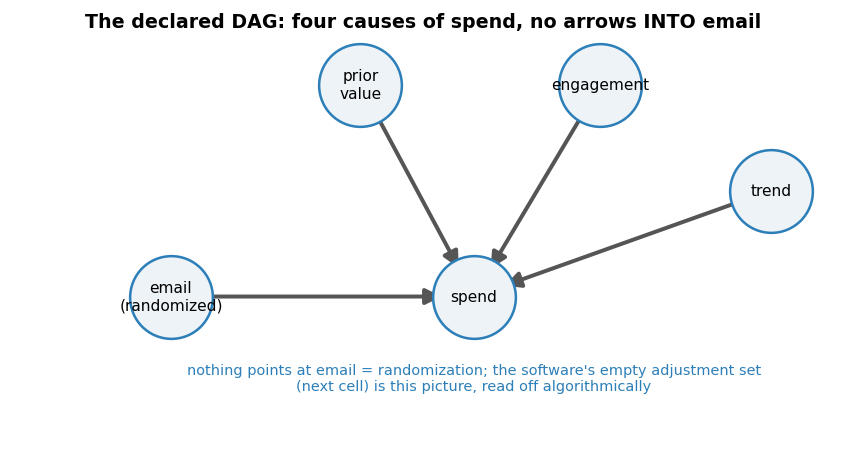

In [3]:
fig, ax = plt.subplots(figsize=(6.6, 3.6))
pos = {"email\n(randomized)": (0.10, 0.32), "prior\nvalue": (0.40, 1.00), "engagement": (0.78, 1.00),
       "trend": (1.05, 0.66), "spend": (0.58, 0.32)}
edges = [("email\n(randomized)", "spend"), ("prior\nvalue", "spend"),
         ("engagement", "spend"), ("trend", "spend")]
plots.draw_dag(ax, pos, edges, title="The declared DAG: four causes of spend, no arrows INTO email")
ax.text(0.58, 0.02, "nothing points at email = randomization; the software's empty adjustment set\n(next cell) is this picture, read off algorithmically",
        ha="center", fontsize=8, color=plots.BLUE)
fig.tight_layout()
# Positivity within segments — trivial under randomization, mandatory discipline on real CRM data
share_seg = df.groupby("prior_value").email.mean()
share_eng = df.groupby(pd.qcut(df.engagement, 3, labels=["low", "mid", "high"]), observed=True).email.mean()
print("P(emailed) by segment:            " + "   ".join(f"{k}: {v:.2f}" for k, v in share_seg.items()))
print("P(emailed) by engagement tercile: " + "   ".join(f"{k}: {v:.2f}" for k, v in share_eng.items()))
print("-> every subgroup has both arms in force (all shares near 0.5): positivity holds, so each segment's")
print("   CATE is a comparison, not an extrapolation. On real data, a share near 0 or 1 voids that segment.")

In [4]:
spec = "spend ~ b_e*email + b_v*is_high + b_ev*email:is_high + b_eg*email:engagement + b_g*engagement + b_tr*trend"
m = pathmc.model(spec, data=df)
print("admissible adjustment set(s) for email->spend:", m.adjustment_sets("email", "spend"))
print("identifiable:", m.is_identifiable("email", "spend"))

admissible adjustment set(s) for email->spend: [set()]
identifiable: True


(An empty adjustment set `[set()]` means "condition on nothing" — correct, because randomization already
made email independent of everything. In an *observational* version we'd see the confounders listed here,
exactly as in notebook 05.)

## 4 · Estimate — fit the structural model

**What `m.fit()` actually samples.** Writing the fitted model out once keeps the Bayesian machinery
honest ($e$=email, $v$=is_high, $g$=engagement, $t$=trend; $i$ indexes customers):

$$
\text{spend}_i \sim \mathcal N\!\big(\mu_i,\;\sigma^2\big),\qquad
\mu_i \;=\; \beta_0+\beta_1 e_i+\beta_2 v_i+\beta_3\,e_i v_i+\beta_4\,e_i g_i+\beta_5 g_i+\beta_6 t_i,
$$

$$
\begin{aligned}
\beta_k &\sim \mathcal N(0,\,10^2)\ \text{for every coefficient (intercept included)},\\[2pt]
\sigma &\sim \text{HalfNormal}(1)\qquad \text{(pathmc's defaults — printed, not trusted, below)}.
\end{aligned}
$$

The likelihood says spend is Gaussian noise around a mean that is linear in the parameters; the priors
are the package defaults, which we print from the model object right after sampling rather than quoting
from documentation. Are they *sensible*? A prior is only "weak" or "strong" **relative to the
likelihood's precision**, never to the raw data scale: with $n=1{,}500$ rows the data speak so loudly
that even the alarming-looking $\text{HalfNormal}(1)$ on a noise level that is truly ≈€6 gets overruled —
the posterior for `sigma_spend` lands where the data put it (printed below). The cell after the fit makes
the same point in reverse with a deliberately dogmatic prior that *rivals* the likelihood's precision and
therefore wins. When segments are thin, the per-segment likelihood is weak and priors regain their power —
that is exactly nb03's partial pooling, previewed in §4b.

The `effects_summary()` table below is the direct read-out: each row is a $\beta$ with its posterior mean and
94% HDI (*Highest Density Interval* — the tightest interval holding 94% of the posterior mass). The two
rows to watch are `b_ev` and `b_eg` — the interaction terms. If their intervals sit clearly away from
zero, the segments genuinely respond differently; that's the statistical backing for writing
segment-specific rules rather than one blanket policy.


In [5]:
idata = m.fit(random_seed=SEED, progressbar=False, **FIT)
print(f"segment model convergence: {est.convergence_report(idata)["summary"]}")
m.effects_summary().round(2)   # the per-coefficient table promised above — b_ev and b_eg are the rows to watch


Initializing NUTS using jitter+adapt_diag...


Multiprocess sampling (4 chains in 4 jobs)


NUTS: [beta_spend, sigma_spend]


Sampling 4 chains for 1_500 tune and 1_500 draw iterations (6_000 + 6_000 draws total) took 7 seconds.


segment model convergence: max r-hat 1.000 - min ESS 3335 - divergences 0


,mean,sd,hdi_3%,hdi_97%
name,,,,
b_e,2.59,0.77,1.18,4.05
b_v,18.39,0.43,17.59,19.21
b_ev,8.13,0.62,6.95,9.26
b_eg,10.19,1.33,7.62,12.58
b_g,3.84,0.93,2.19,5.70
b_tr,0.29,0.01,0.27,0.32


**Reading the sampler's health check.** Those three numbers say whether the MCMC sampler — the algorithm that draws samples from the posterior — actually converged. **R-hat** compares the variance *within* each chain to the variance *across* chains; 1.00 is perfect and **≤ 1.01 is the usual pass bar** (above it the chains disagree and the numbers aren't safe to read). **ESS** (effective sample size) is how many *independent* draws our autocorrelated chains are worth — a few hundred is ample for a posterior mean or a 94% interval. **Divergences** are steps where the sampler broke down and silently distrusts that region; **you want 0**. Here all three pass, so the posterior below is trustworthy. (Under the FAST teaching profile the chains are deliberately short, so R-hat can drift to ~1.02 and PyMC may print a "problems during sampling" notice — a benign artifact of the small draw count that clears in a FULL run; §5b's multi-seed recovery is the real backstop that the estimates are sound.)

In [6]:
# Priors: shown, not trusted blind — then deliberately stress-tested
print("pathmc's default priors for this model:")
print(m.priors())
sig_post = float(idata.posterior["sigma_spend"].mean())
print(f"\nposterior sigma_spend ≈ €{sig_post:.2f} (true noise €6): the HalfNormal(1) prior 'wanted' a far smaller")
print("sigma, but 1,500 rows of likelihood overruled it — weak/strong is about the likelihood, not the prior.")

# The reverse experiment: a dogmatic prior that RIVALS the likelihood's precision. The betas' posterior
# sds in the table above are ~€0.4–1.3; a Normal(0, 0.1) prior is ~an order of magnitude MORE precise
# than the data, so it should win — and it does. (Secondary fit; sampler chatter silenced as in §5b.)
import logging
_pml = logging.getLogger("pymc"); _lvl0 = _pml.level; _pml.setLevel(logging.CRITICAL + 1)
m_tight = pathmc.model(spec, data=df)
m_tight.set_priors({"beta_spend": pathmc.Prior("Normal", mu=0, sigma=0.1)})
m_tight.fit(random_seed=SEED, progressbar=False, **FIT)
ct_hi = m_tight.cate("spend", "email", condition={"is_high": 1.0, "engagement": 0.5}, values=(0, 1))
c_ref = m.cate("spend", "email", condition={"is_high": 1.0, "engagement": 0.5}, values=(0, 1))
_pml.setLevel(_lvl0)
print(f"\nsame data, beta prior Normal(0, 0.1): high-value CATE collapses to €{ct_hi.mean():.2f} "
      f"(default priors: €{c_ref.mean():.2f})")
print("-> the posterior is always prior x likelihood; the defaults were harmless only because n made the")
print("   likelihood sharp. With dozens of THIN segments the per-segment likelihood is weak — exactly when")
print("   priors must be chosen (partial pooling, nb03), not defaulted.")

pathmc's default priors for this model:
Priors:
  beta_spend: Normal(mu=0, sigma=10)
  sigma_spend: HalfNormal(sigma=1)

posterior sigma_spend ≈ €5.93 (true noise €6): the HalfNormal(1) prior 'wanted' a far smaller
sigma, but 1,500 rows of likelihood overruled it — weak/strong is about the likelihood, not the prior.



same data, beta prior Normal(0, 0.1): high-value CATE collapses to €0.68 (default priors: €15.82)
-> the posterior is always prior x likelihood; the defaults were harmless only because n made the
   likelihood sharp. With dozens of THIN segments the per-segment likelihood is weak — exactly when
   priors must be chosen (partial pooling, nb03), not defaulted.


**Model criticism — the posterior predictive check (PPC).** Before we read effects off a structural
model, we ask whether it can even *regenerate the data it was fit to*. We draw replicated spend vectors
from the fitted model — $y^{rep}_i = \mu_i^{(s)} + \varepsilon,\ \varepsilon \sim \mathcal N(0, \sigma^{(s)})$,
one replicate per posterior draw $s$ — and overlay them on the observed spend distribution, the same
discipline as notebook 01. If the real data looked nothing like what the model can generate (wrong
spread, missed skew), the effect estimates downstream would be untrustworthy no matter how tight their
intervals. A model that cannot reproduce the outcome's shape has no business issuing counterfactuals
about it.

PPC: 90% of observed spend falls inside its replicates' 5–95% band (≈90% if calibrated) — no gross misfit; the model can regenerate the data it explains.


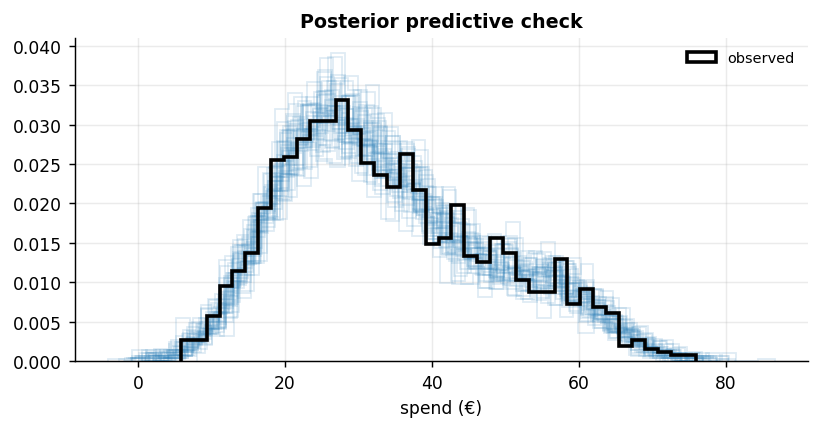

In [7]:
import logging
_pml = logging.getLogger("pymc"); _lvl0 = _pml.level; _pml.setLevel(logging.CRITICAL + 1)
ppc = m.predict(progressbar=False)                       # posterior-predictive replicates of spend
_pml.setLevel(_lvl0)
y_rep = ppc["posterior_predictive"]["spend"].values.reshape(-1, len(df))
sel = np.random.default_rng(SEED).choice(y_rep.shape[0], size=40, replace=False)
fig, ax = plt.subplots(figsize=(6.4, 3.4))
plots.ppc_plot(ax, df.spend.values, y_rep[sel])
ax.set_xlabel("spend (€)")
fig.tight_layout()
_lo, _hi = np.percentile(y_rep, [5, 95], axis=0)         # per-customer 5–95% replicate band
ppc_cov = float(np.mean((df.spend.values >= _lo) & (df.spend.values <= _hi)))
print(f"PPC: {ppc_cov:.0%} of observed spend falls inside its replicates' 5–95% band (≈90% if calibrated) — "
      + ("no gross misfit; the model can regenerate the data it explains."
         if 0.82 <= ppc_cov <= 0.98 else "possible misfit — inspect the tails before reading effects."))

### 4b · Three ways to get a segment effect — and why the interaction model wins

The interaction model is not the only way to answer "does the effect differ by segment?" — it is the best
of three classic options, and seeing all three on one axis is the fastest way to understand what the
interaction terms buy. Writing $\tau_s$ for segment $s$'s effect and $n_s$ for its row count:

$$
\begin{aligned}
&\text{(a) full pooling: } \tau_s \equiv \tau\ \ \forall s\\[2pt]
&\text{(b) no pooling: } \tau_s \text{ estimated from the } n_s \text{ rows of segment } s \text{ alone}\\[2pt]
&\text{(c) interaction: } \tau_s = \beta_1 + \beta_3\, s,\ \text{nuisances shared.}
\end{aligned}
$$

- **(a) Full pooling** — the same structural model with *no* interaction terms. Everyone is assigned the
  ATE. This is "treat everyone as the average" *as a model* rather than as a policy — and if real
  heterogeneity exists it is wrong for **every** segment at once.
- **(b) No pooling** — split the sample and fit `spend ~ email + engagement + trend` separately inside
  each segment. Unbiased for each segment's mean effect, but wasteful: each half re-estimates $\sigma$,
  the engagement slope and the trend slope from its own rows only — and there is no single posterior for
  the *gap* between segments, nor for a continuous moderation profile that crosses them.
- **(c) The interaction model** already fitted. Because the binary moderator is *saturated* by the
  $e\cdot v$ term — that term gives it one free parameter per level, so it can hit each segment's
  mean exactly, just as separate fits would — it reproduces the no-pooling segment *means* — while sharing every nuisance parameter
  across segments and carrying the gap ($\beta_3$) and the engagement slope ($\beta_4$) as first-class
  posterior quantities.

With two large segments the pure *efficiency* difference is modest — both halves still have hundreds of
rows, and the printed interval widths below quantify exactly how much (or little) sharing nuisances buys
here. The trade turns brutal as segments multiply and thin: with 20 segments of 75 customers, every
no-pooling fit is noise. The cure then is **partial pooling** — treat the segment effects as draws from a
population,

$$\tau_s \sim \mathcal N(\mu_\tau,\ \sigma_\tau^2),$$

where $\mu_\tau$ is the average effect across segments and $\sigma_\tau$ is how much the segments genuinely differ — estimating $\sigma_\tau$ from the data is what decides how hard to shrink — so noisy, thin segments are shrunk toward the population mean and borrow strength from fat ones. That is
notebook 03's random-slopes machinery; here we've just turned the usual throwaway caveat into an equation.

full pooling answers €10.79 for BOTH segments (truths €7 / €16) — wrong for each
90% interval widths — low : no-pooling €1.32  vs  interaction €1.28
                      high: no-pooling €1.65  vs  interaction €1.61
similar widths here (both segments still have hundreds of rows); the no-pooling penalty grows as
segments thin — and only the interaction model carries a posterior for the GAP (b_ev) and the
engagement slope (b_eg) at all.


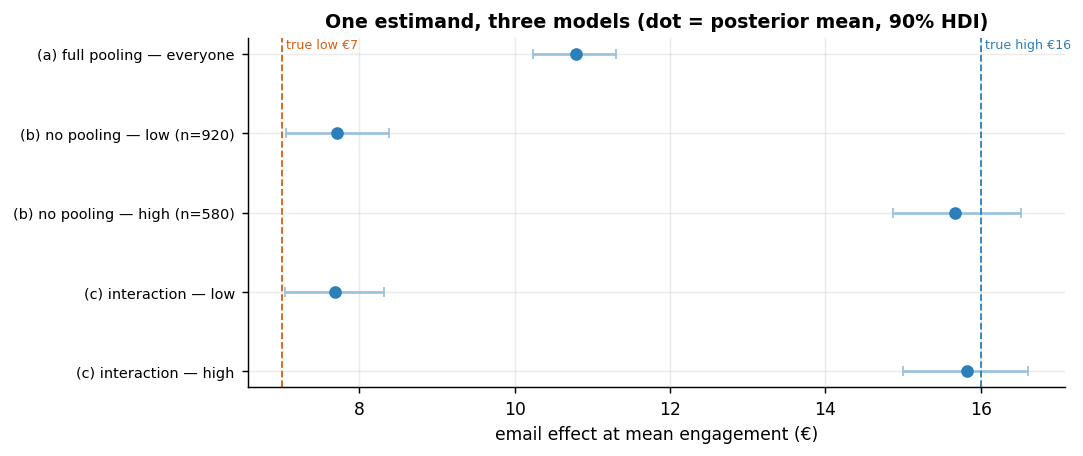

In [8]:
# (a) full pooling: no interactions — one effect for everybody
# (b) no pooling:  a separate fit inside each segment
# (c) the interaction model `m`, already fitted
# (secondary fits; sampler chatter silenced as in §5b)
import logging
_pml = logging.getLogger("pymc"); _lvl0 = _pml.level; _pml.setLevel(logging.CRITICAL + 1)
m_pool = pathmc.model("spend ~ b_e*email + b_v*is_high + b_g*engagement + b_tr*trend", data=df)
m_pool.fit(random_seed=SEED, progressbar=False, **FIT)
c_pool = m_pool.cate("spend", "email", condition={"is_high": 1.0, "engagement": 0.5}, values=(0, 1))
split = {}
for h in (0.0, 1.0):
    m_s = pathmc.model("spend ~ b_e*email + b_g*engagement + b_tr*trend", data=df[df.is_high == h])
    m_s.fit(random_seed=SEED, progressbar=False, **FIT)
    split[h] = m_s.cate("spend", "email", condition={"engagement": 0.5}, values=(0, 1))
_pml.setLevel(_lvl0)
c_int = {h: m.cate("spend", "email", condition={"is_high": h, "engagement": 0.5}, values=(0, 1))
         for h in (0.0, 1.0)}

n_lo, n_hi = int((df.is_high == 0).sum()), int((df.is_high == 1).sum())
rows = [("(a) full pooling — everyone", c_pool),
        (f"(b) no pooling — low (n={n_lo})", split[0.0]),
        (f"(b) no pooling — high (n={n_hi})", split[1.0]),
        ("(c) interaction — low", c_int[0.0]),
        ("(c) interaction — high", c_int[1.0])]
labels = [r[0] for r in rows]
means = [r[1].mean() for r in rows]
bounds = [r[1].hdi(prob=0.90) for r in rows]
los, his = [b[0] for b in bounds], [b[1] for b in bounds]
fig, ax = plt.subplots(figsize=(8.4, 3.6))
plots.forest_plot(ax, labels, means, los, his,
                  title="One estimand, three models (dot = posterior mean, 90% HDI)",
                  xlabel="email effect at mean engagement (€)")
ax.axvline(true_effect["low"], color=plots.ORANGE, ls="--", lw=1)
ax.axvline(true_effect["high"], color=plots.BLUE, ls="--", lw=1)
ax.text(true_effect["low"], ax.get_ylim()[1], " true low €7", fontsize=7, color=plots.ORANGE, va="top")
ax.text(true_effect["high"], ax.get_ylim()[1], " true high €16", fontsize=7, color=plots.BLUE, va="top")
fig.tight_layout()
w = {lab: hi - lo for lab, lo, hi in zip(labels, los, his)}
print(f"full pooling answers €{c_pool.mean():.2f} for BOTH segments (truths €7 / €16) — wrong for each")
print(f"90% interval widths — low : no-pooling €{w[labels[1]]:.2f}  vs  interaction €{w[labels[3]]:.2f}")
print(f"                      high: no-pooling €{w[labels[2]]:.2f}  vs  interaction €{w[labels[4]]:.2f}")
print("similar widths here (both segments still have hundreds of rows); the no-pooling penalty grows as")
print("segments thin — and only the interaction model carries a posterior for the GAP (b_ev) and the")
print("engagement slope (b_eg) at all.")

**Reading the forest plot.** Full pooling (a) lands between the two truths and is therefore wrong for
*both* segments at once — too optimistic about low-value customers, too pessimistic about high-value
ones. This is the statistical face of the "cost of pooling" that Step 6 prices in campaign euros: the
bias doesn't average out, it mis-targets both halves of the base. No pooling (b) is centred correctly but
pays for re-learning $\sigma$ and the nuisance slopes inside each half — with segments this large the
price is small (compare the printed widths), which is itself worth knowing: the interaction model's
advantage here is **coherence**, not raw precision. Only (c) delivers, from one fit, the two segment
effects *plus* a posterior for their difference ($\beta_3$ — Step 5's "is the gap real?") *plus* the
continuous engagement profile ($\beta_4$) — quantities (b) can only bolt together from two independent
posteriors and (a) denies exist. One estimand, three bias–variance trade-offs; (c) sits at the sweet spot
until segments get thin, at which point partial pooling (nb03) takes over.

**DAG falsification — the check you'd run on real CRM data.** Recovery-vs-truth is only available in simulation; on real data you instead test the DAG's *implied* conditional independences against the data — a wrong DAG shows up as an independence the graph predicts but the data violate.

In [9]:
imp = m.test_implications(alpha=0.05)
print(f"DAG falsification: {imp.n_tests} implied independences tested, {imp.n_violations} violated at alpha=0.05 "
      f"({'graph consistent with the data' if imp.n_violations==0 else 'graph MISSPECIFIED — see violations'}).")

DAG falsification: 6 implied independences tested, 0 violated at alpha=0.05 (graph consistent with the data).


## 5 · Validate — recover the effects, the gap, and the moderation profile

Four checks:

1. **Segment CATEs** vs the planted **€7 / €16** (the low/high segment averages at mean engagement,
   0.5) — with **credible intervals** (a credible interval is the Bayesian analog of a confidence interval: a range the parameter falls in with the stated probability, given the data).
2. **Is the gap real?** the interaction posterior $\beta_3$; if it clearly excludes zero, the
   segments truly differ (not noise).
3. **The continuous moderation profile** — CATE as a smooth function of engagement, recovered
   vs the true `3 + 9·is_high + 8·engagement` line. This is the payoff of modelling the
   continuous moderator rather than crudely binning customers into two groups.
4. **Per-customer recovery** — the effect predicted for each individual customer (from the fitted
   moderation coefficients) against their true effect, on the 45° line. Recovering *segment averages*
   is easy; recovering the effect for each *individual* is the real test.

In [10]:
ate = m.ate("spend", "email", values=(0, 1))
cate_high = m.cate("spend", "email", condition={"is_high": 1.0, "engagement": 0.5}, values=(0, 1))
cate_low = m.cate("spend", "email", condition={"is_high": 0.0, "engagement": 0.5}, values=(0, 1))
b_ev = idata.posterior["beta_spend"].sel(spend_predictors="email:is_high").values.ravel()
b_eg = idata.posterior["beta_spend"].sel(spend_predictors="email:engagement").values.ravel()
p_gap = (b_ev > 0).mean()
p_str = "> 0.999" if p_gap > 0.999 else f"{p_gap:.3f}"
def fmt94(res):                                   # pretty-print an EstimandResult's 94% HDI
    lo, hi = res.hdi(prob=0.94)
    return f"94% HDI [€{lo:.2f}, €{hi:.2f}]"
print(f"ATE (pooled)       €{ate.mean():5.2f}   {fmt94(ate)}")
print(f"CATE low  (eng .5) €{cate_low.mean():5.2f}  (true {true_effect['low']:.1f})   {fmt94(cate_low)}")
print(f"CATE high (eng .5) €{cate_high.mean():5.2f}  (true {true_effect['high']:.1f})   {fmt94(cate_high)}")
print(f"Interaction β(email:is_high) mean €{b_ev.mean():.2f} (true 9.0), P(>0) = {p_str} → gap is "
      + ("REAL" if p_gap > 0.95 else "uncertain"))
eg_lo, eg_hi = np.quantile(b_eg, [0.05, 0.95])
print(f"Interaction β(email:engagement) mean €{b_eg.mean():.2f} (true 8.0), 90% credible interval "
      f"[€{eg_lo:.2f}, €{eg_hi:.2f}] — {'covers' if eg_lo <= 8.0 <= eg_hi else 'misses'} the planted €8.0 on "
      f"this draw; the moderation panel below shows where that slope error pulls the fitted line off the truth")

ATE (pooled)       €10.80   94% HDI [€10.22, €11.37]
CATE low  (eng .5) € 7.69  (true 7.0)   94% HDI [€6.99, €8.46]
CATE high (eng .5) €15.82  (true 16.0)   94% HDI [€14.88, €16.72]
Interaction β(email:is_high) mean €8.13 (true 9.0), P(>0) = > 0.999 → gap is REAL
Interaction β(email:engagement) mean €10.19 (true 8.0), 90% credible interval [€7.95, €12.35] — covers the planted €8.0 on this draw; the moderation panel below shows where that slope error pulls the fitted line off the truth


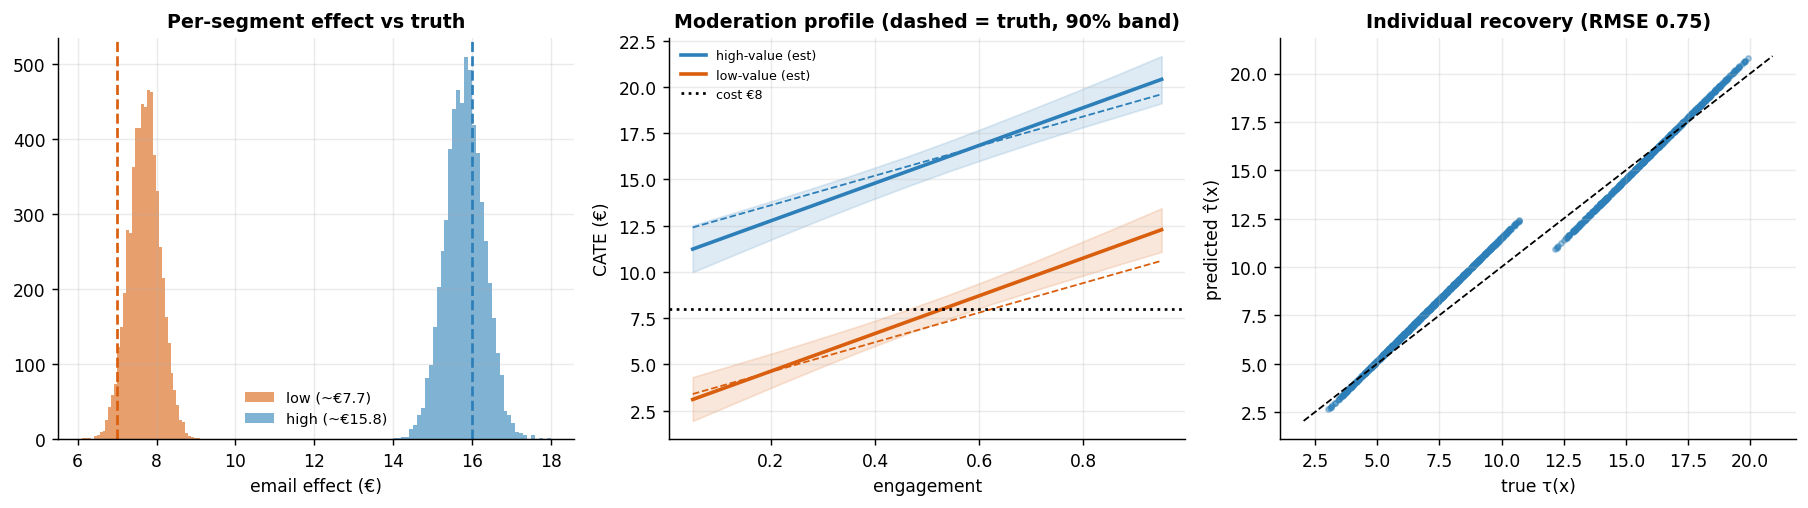

In [11]:
fig, ax = plt.subplots(1, 3, figsize=(14, 4))
# (1) segment posteriors vs truth
lo_d, hi_d = cate_low.draws(), cate_high.draws()
ax[0].hist(lo_d, bins=40, color=plots.ORANGE, alpha=0.6, label=f"low (~€{lo_d.mean():.1f})")
ax[0].hist(hi_d, bins=40, color=plots.BLUE, alpha=0.6, label=f"high (~€{hi_d.mean():.1f})")
ax[0].axvline(true_effect["low"], color=plots.ORANGE, ls="--"); ax[0].axvline(true_effect["high"], color=plots.BLUE, ls="--")
ax[0].set_xlabel("email effect (€)"); ax[0].set_title("Per-segment effect vs truth"); ax[0].legend(frameon=False, fontsize=8)
# (2) continuous moderation profile
eng_grid = np.linspace(0.05, 0.95, 12)
for hv, col, lab in [(1.0, plots.BLUE, "high"), (0.0, plots.ORANGE, "low")]:
    means, los, his = [], [], []
    for g in eng_grid:
        c = m.cate("spend", "email", condition={"is_high": hv, "engagement": float(g)}, values=(0,1))
        d = c.draws(); means.append(d.mean()); los.append(np.quantile(d,.05)); his.append(np.quantile(d,.95))
    ax[1].plot(eng_grid, means, color=col, lw=2, label=f"{lab}-value (est)")
    ax[1].fill_between(eng_grid, los, his, color=col, alpha=0.15)
    true_line = 3 + 9*hv + 8*eng_grid
    ax[1].plot(eng_grid, true_line, color=col, ls="--", lw=1)
ax[1].axhline(COST, color="k", ls=":", label=f"cost €{COST:.0f}")
ax[1].set_xlabel("engagement"); ax[1].set_ylabel("CATE (€)"); ax[1].set_title("Moderation profile (dashed = truth, 90% band)")
ax[1].legend(frameon=False, fontsize=7)
# (3) per-customer recovery: predicted τ̂(x) from the moderation coefficients vs true τ
post = idata.posterior
be = post["beta_spend"].sel(spend_predictors="email").values.ravel()
bev = post["beta_spend"].sel(spend_predictors="email:is_high").values.ravel()
beg = post["beta_spend"].sel(spend_predictors="email:engagement").values.ravel()
tau_hat = (be.mean() + bev.mean()*df.is_high.values + beg.mean()*df.engagement.values)
ax[2].scatter(df.tau, tau_hat, s=8, alpha=0.4, color=plots.BLUE)
lim = [df.tau.min()-1, df.tau.max()+1]; ax[2].plot(lim, lim, "k--", lw=1)
rmse = np.sqrt(np.mean((tau_hat - df.tau.values)**2))
ax[2].set_xlabel("true τ(x)"); ax[2].set_ylabel("predicted τ̂(x)"); ax[2].set_title(f"Individual recovery (RMSE {rmse:.2f})")
fig.tight_layout()

**How to read those three panels.** *Left* — the two segment-effect posteriors land close to their
planted truths (dashed lines) and barely overlap, so the model both **recovers** the effects and **separates**
the segments (the low-value posterior runs ≈€0.7 high on this draw — §5b shows the bias vanishes across fresh samples). *Middle* — the estimated CATE (solid) tracks the true `3 + 9·is_high + 8·engagement` line
(dashed) over most of the engagement range — though this draw's interaction slope runs high (≈€10 fitted vs €8.0 planted — the exact figure is printed above), so the fitted line pulls above the truth at high engagement: modelling the *continuous* moderator paid off, because the effect
clearly rises with engagement rather than being a flat per-segment number. Note where each line crosses the €8
cost line — that's the **break-even engagement**, the level above which a customer becomes worth emailing; we
quantify it (with a 94% HDI) in the decide step below. *Right* — predicted vs
true effect *per customer* hugs the 45° line (low RMSE), confirming recovery at the individual level, not just
on segment averages.

### 5b · Recovery across many seeds — unbiased *and* calibrated?

A single sample can land a little off; the real test of an estimator is whether it is **centred on the truth over repeated samples** (unbiased, not just lucky here) and whether its intervals **cover** the truth at their stated rate. We refit on many fresh samples and check both. (The per-seed refits are deliberately small, fast fits — enough for the bias/coverage tallies we read off them; their sampler chatter is silenced below.) We track three quantities per
refit: the two segment CATEs *and* the low-value **break-even engagement** $g^{*}$ — a *ratio* of
coefficients, the estimand the decision step will warn is fragile near a crossing — so that when Step 6
reads its break-even off one sample, we already know how that ratio behaves across many.

low -value: mean €7.05 (true €7)  bias +0.05  sd 0.37  ·  90% HDI covers truth in 19/20 seeds
high-value: mean €15.98 (true €16)  bias -0.02  sd 0.49  ·  90% HDI covers truth in 18/20 seeds
g* break-even : mean 0.618 (true 0.625)  bias -0.007  sd 0.047  ·  94% HDI covers truth in 19/20 seeds
   -> the ratio's coverage sits near nominal across fresh samples: a one-sample miss (see the decide step) reads as bad luck near the crossing, not systematic under-coverage.


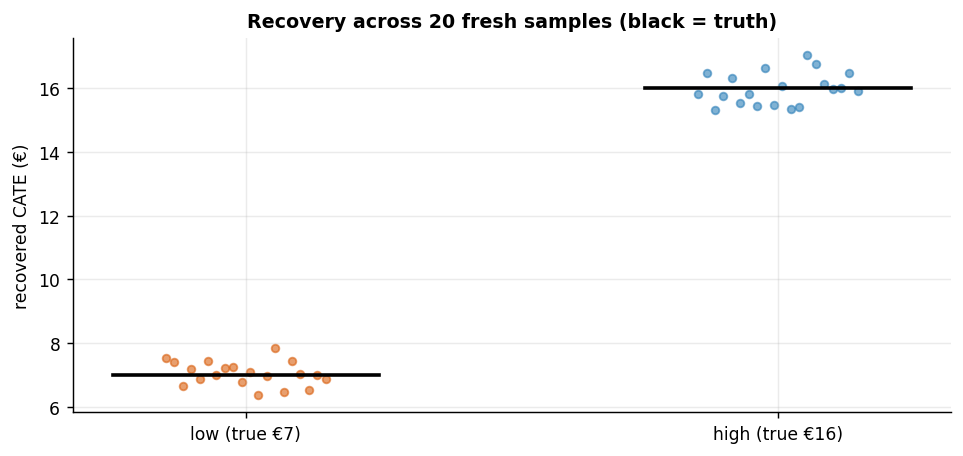

In [12]:
# --- Recovery across many seeds: unbiased? calibrated? and does the RATIO estimand g* behave? ---
NSEED = 8 if FAST else 20
LOOP = dict(draws=250, tune=250, chains=2, cores=1)     # small per-seed fit — recovery, not a headline posterior
import logging
_pml = logging.getLogger("pymc"); _pml_lvl = _pml.level   # silence the per-seed refits' sampler chatter
_pml.setLevel(logging.CRITICAL + 1)                       # (disclosed above; the same trick pymc's own
# _quiet_logging uses — the low-ESS notice is logged at ERROR level); restored at the end of the cell

def hdi94(x, prob=0.94):
    """Shortest interval holding `prob` of the mass. Hand-rolled rather than EstimandResult.hdi because
    we apply it to DERIVED draws — ratios like g* = (COST - b_e)/b_eg — that never live inside a pathmc
    result object. Reused by the decision cells below."""
    xs = np.sort(np.asarray(x)); n = len(xs); k = int(np.floor(prob * n))
    i = int(np.argmin(xs[k:] - xs[:n - k]))
    return xs[i], xs[i + k]

G_TRUE = (COST - 3.0) / 8.0                    # true low-value break-even: 3 + 8g = 8  ->  g* = 0.625
rec = {"low": [], "high": []}; cov = {"low": 0, "high": 0}
g_rec, g_cov = [], 0
for sd in range(NSEED):
    dd, tt = dgp.segment_customers(n=1500, seed=300 + sd)
    dd["is_high"] = (dd["prior_value"] == "high").astype(float)
    ms = pathmc.model(spec, data=dd); isd = ms.fit(random_seed=1, progressbar=False, **LOOP)
    for lab, hv in [("low", 0.0), ("high", 1.0)]:
        c = ms.cate("spend", "email", condition={"is_high": hv, "engagement": 0.5}, values=(0, 1))
        rec[lab].append(c.mean()); lo, hi = c.hdi(prob=0.90); cov[lab] += int(lo <= tt[lab] <= hi)
    be_s = isd.posterior["beta_spend"].sel(spend_predictors="email").values.ravel()
    beg_s = isd.posterior["beta_spend"].sel(spend_predictors="email:engagement").values.ravel()
    g_s = (COST - be_s) / beg_s                # per-draw low-value break-even in THIS fresh sample
    g_rec.append(g_s.mean()); glo, ghi = hdi94(g_s); g_cov += int(glo <= G_TRUE <= ghi)
fig, ax = plt.subplots(figsize=(7.5, 3.6))
for lab, col, x0 in [("low", plots.ORANGE, 0), ("high", plots.BLUE, 1)]:
    a = np.array(rec[lab]); ax.scatter(x0 + np.linspace(-0.15, 0.15, len(a)), a, s=18, color=col, alpha=0.6)
    ax.plot([x0 - 0.25, x0 + 0.25], [true_effect[lab]] * 2, color="k", lw=2)
ax.set_xticks([0, 1]); ax.set_xticklabels([f"low (true €{true_effect['low']:.0f})", f"high (true €{true_effect['high']:.0f})"])
ax.set_ylabel("recovered CATE (€)"); ax.set_title(f"Recovery across {NSEED} fresh samples (black = truth)"); fig.tight_layout()
for lab in ("low", "high"):
    a = np.array(rec[lab])
    print(f"{lab:4s}-value: mean €{a.mean():.2f} (true €{true_effect[lab]:.0f})  bias {a.mean()-true_effect[lab]:+.2f}  "
          f"sd {a.std():.2f}  ·  90% HDI covers truth in {cov[lab]}/{NSEED} seeds")
ga = np.array(g_rec)
print(f"g* break-even : mean {ga.mean():.3f} (true {G_TRUE:.3f})  bias {ga.mean()-G_TRUE:+.3f}  "
      f"sd {ga.std():.3f}  ·  94% HDI covers truth in {g_cov}/{NSEED} seeds")
print("   -> " + ("the ratio's coverage sits near nominal across fresh samples: a one-sample miss (see the "
                  "decide step) reads as bad luck near the crossing, not systematic under-coverage."
                  if g_cov / NSEED >= 0.75 else
                  "the ratio UNDER-covers across fresh samples: break-even HDIs run too narrow — treat the "
                  "decide step's printed cutoff band as optimistic."))
_pml.setLevel(_pml_lvl)

### 5c · Two ways segment analysis goes wrong: fishing, and underpowered interactions

The single most famous failure mode of segment analysis isn't a bias in any estimator — it's **subgroup
fishing** (multiple comparisons). Slice a campaign twenty ways and *something* will look responsive by
chance; the analyst then writes a confident slide about "segment 13". Before trusting our own gap, we
stage the trap on this very dataset: keep the real outcome and the real randomized email, but generate
**20 pure-noise binary "segments"** — coin-flip labels with, by construction, zero true moderation — and
test each one's effect gap the way a naive analyst would (a 95% interval on the treated-minus-control
difference between the two halves of each label). Each individual test is honest; **the batch is not**:
20 independent nulls at the 5% level yield about one false "discovery" on average.

The second failure mode is the mirror image: real interactions are **intrinsically hard to detect**. In a
balanced 50/50 test split into two equal segments, the segment *gap* is the difference of two segment
effects, so its sampling variance is the **sum** of theirs — and each segment effect is estimated from
half the sample (the variance of an estimate scales like $1/n$, so halving the sample doubles it):

$$
\mathrm{Var}(\hat\beta_3) \;=\; \mathrm{Var}(\hat\tau_{\text{high}}) + \mathrm{Var}(\hat\tau_{\text{low}})
\;\approx\; 2\,\mathrm{Var}(\hat\tau_{\text{pooled}}) + 2\,\mathrm{Var}(\hat\tau_{\text{pooled}})
\;=\; 4\,\mathrm{Var}(\hat\tau_{\text{pooled}}),
$$

where $\hat\beta_3$ is the interaction (gap) estimate and $\hat\tau_{\text{pooled}}$ the ATE estimate
on the same $n$. The gap's standard error is therefore ≈ **2×** the ATE's. Required sample grows with $(\text{SE}/\text{effect})^2$, so a gap that carries **2×** the SE *and* — being half the size of the
main effect — half the signal needs $(2/\tfrac12)^2 = \mathbf{16}\times$ the rows for equal power. That is
Gelman's rule of thumb: you need **~16× the sample** to detect an interaction *half* the size of the main
effect with the same power. Interactions whisper; averages shout. We verify the 2× on our own posterior below, then
use the same arithmetic to size the follow-up test that Step 6's cautious low-value verdict calls for.

1 of 20 pure-noise moderators produce a 95%-significant effect gap (~1 expected by chance) — 'responsive segments' manufactured from coin flips.

posterior sd — ATE: €0.31   segment gap b_ev: €0.62   ratio 2.0x (theory for a clean 50/50 split: 2x)
low-value CATE €7.69 vs cost €8: posterior sd €0.39 on n = 1,500.
posterior sd shrinks like sqrt(n0/n); IF the truth sits at today's mean, n ≈ 6,450 customers
puts 95% of the low-value posterior on one side of the cost line — 'run a bigger test' now has a
number attached (the closer the effect is to the cost, the more brutally that number grows).


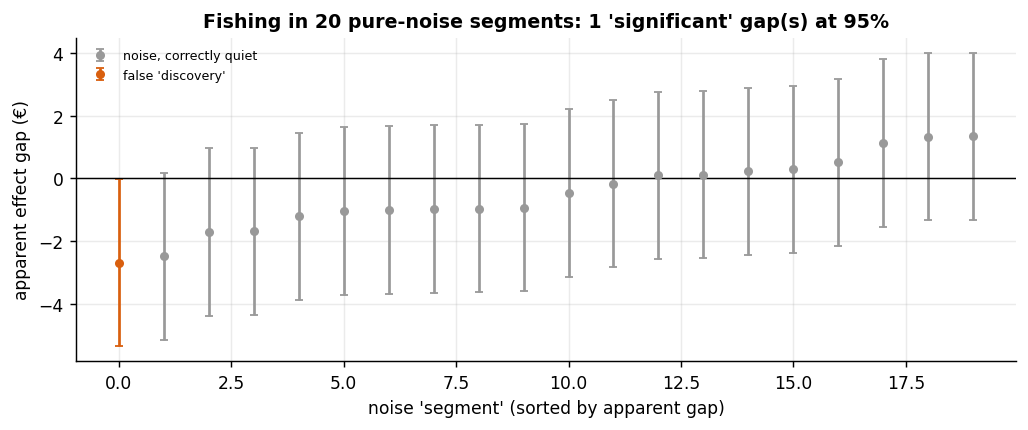

In [13]:
# --- (i) the fishing demo: 20 noise moderators, honest tests, dishonest batch -----------------
rng_fish = np.random.default_rng(123)
K = 20                                           # 20 tests at alpha = 0.05  ->  ~1 false discovery expected
Tm = df.email.values == 1; y_obs = df.spend.values
gaps, ses = [], []
for k in range(K):
    s = rng_fish.integers(0, 2, len(df)).astype(bool)        # a pure-noise "segment" label
    gap, var = 0.0, 0.0
    for sv, sign in ((True, 1), (False, -1)):
        arm1, arm0 = y_obs[Tm & (s == sv)], y_obs[~Tm & (s == sv)]
        gap += sign * (arm1.mean() - arm0.mean())            # difference-in-gaps across the two halves
        var += arm1.var(ddof=1) / arm1.size + arm0.var(ddof=1) / arm0.size
    gaps.append(gap); ses.append(np.sqrt(var))
gaps, ses = np.array(gaps), np.array(ses)
false_hits = np.abs(gaps) > 1.96 * ses
fig, ax = plt.subplots(figsize=(8, 3.4))
order = np.argsort(gaps)
for grp, colv, lab in ((~false_hits[order], plots.GREY, "noise, correctly quiet"),
                       (false_hits[order], plots.ORANGE, "false 'discovery'")):
    ii = np.where(grp)[0]
    if ii.size:
        ax.errorbar(ii, gaps[order][ii], yerr=1.96 * ses[order][ii], fmt="o", ms=4, ls="none",
                    color=colv, ecolor=colv, capsize=2, label=lab)
ax.axhline(0, color="k", lw=0.8); ax.legend(frameon=False, fontsize=7)
ax.set_xlabel("noise 'segment' (sorted by apparent gap)"); ax.set_ylabel("apparent effect gap (€)")
ax.set_title(f"Fishing in {K} pure-noise segments: {int(false_hits.sum())} 'significant' gap(s) at 95%")
fig.tight_layout()
print(f"{int(false_hits.sum())} of {K} pure-noise moderators produce a 95%-significant effect gap "
      f"(~{0.05 * K:.0f} expected by chance) — 'responsive segments' manufactured from coin flips.")

# --- (ii) interactions are ~2x noisier than the average: verify on OUR posterior --------------
ate_sd = ate.draws().std(); gap_sd = b_ev.std()
print(f"\nposterior sd — ATE: €{ate_sd:.2f}   segment gap b_ev: €{gap_sd:.2f}   ratio {gap_sd / ate_sd:.1f}x "
      f"(theory for a clean 50/50 split: 2x)")

# --- (iii) size the follow-up test the low-value verdict calls for ----------------------------
lo_draws_ = cate_low.draws(); sd_lo, mu_lo = lo_draws_.std(), lo_draws_.mean()
z95 = 1.645                                       # 95% one-sided decisiveness
n_decisive = int(np.ceil(len(df) * (z95 * sd_lo / max(abs(mu_lo - COST), 1e-9)) ** 2))
print(f"low-value CATE €{mu_lo:.2f} vs cost €{COST:.0f}: posterior sd €{sd_lo:.2f} on n = {len(df):,}.")
print(f"posterior sd shrinks like sqrt(n0/n); IF the truth sits at today's mean, n ≈ {n_decisive:,} customers")
print("puts 95% of the low-value posterior on one side of the cost line — 'run a bigger test' now has a")
print("number attached (the closer the effect is to the cost, the more brutally that number grows).")

**Read-out.** The batch of noise segments delivers what multiplicity theory promises — on the order of
one sham "responsive segment" per twenty tests (any orange interval excludes zero purely by luck; the
count is printed in the title). The defences, in order of cheapness: **pre-register** the segments you
will act on before the campaign runs; report **posterior probabilities** rather than one-shot
significance stars; and when you genuinely must scan many segments, use **shrinkage / partial pooling**
(nb03), which pulls each segment's estimate toward the population mean in proportion to its noisiness —
fishing dies when noisy estimates aren't allowed to stand alone. Note what this notebook's own analysis
did: *two pre-declared moderators* (value tier, engagement), each with a prior business rationale — that
design choice, more than any model, is the protection.

The power arithmetic explains Step 6's caution about the low-value segment. The quantity that decides
whether segments *differ* ($\beta_3$) is about twice as noisy as the quantity that decides whether the
campaign *works* (the ATE) — on the same data (the printed ratio). Detecting that a gap exists is easy
here only because the planted gap is huge; resolving a **borderline** segment call — low-value's effect
against the €8 cost — needs the multiplied sample the sizing line prints. Budget accordingly: an A/B test
sized to measure the average is usually ~4× too small to measure *who* it works on.

### 5d · What if the model is wrong? Misspecification stress + a model-free cross-check

Time for an uncomfortable admission: the structural model recovered the truth partly because **we handed
it the true functional form** — the simulator's linear `email:engagement` moderation was copied straight
into `spec`. On real data nobody hands you the form; you guess it. So we do what an honest analyst must:
**break the model on purpose and watch what fails**. We refit with the engagement moderation *omitted*
(`spec_bad` drops `email:engagement` — the guess "engagement doesn't moderate the email", which would
sound perfectly reasonable before seeing the truth) and ask three questions: what happens to the
*segment-level* answers? what happens to the *individual-level* answers and the break-even rule? and —
the sharpest question — **does the DAG-falsification test from Step 4 catch the error?**

segment CATEs at mean engagement — wrong model: low €7.69 / high €15.72   (true-form model: €7.69 / €15.82)
per-customer recovery RMSE:  €0.75 (true form)  ->  €1.90 (moderation omitted)
break-even engagement (COST - b_e)/b_eg: UNANSWERABLE — the wrong model has no b_eg, so Step 6's
  'send low-value above engagement g*' rule cannot even be written down.
DAG falsification on the wrong model: 6 implied independences tested, 0 violated -> the graph test does NOT flag it — expected, and the lecture point below.


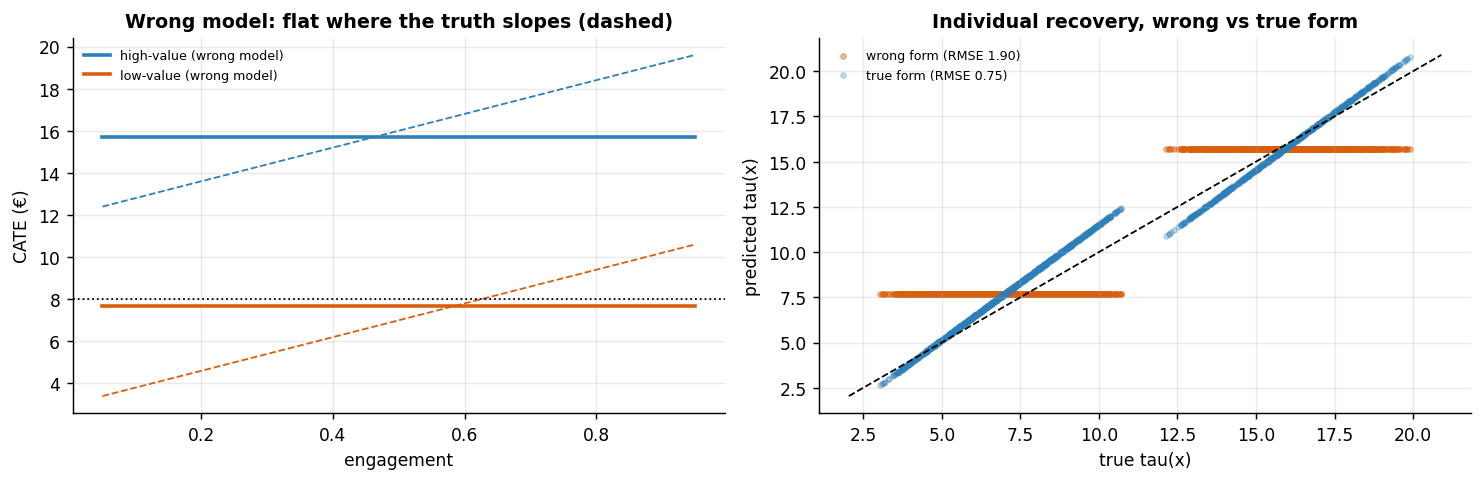

In [14]:
# The wrong (but plausible) model: engagement still predicts spend, it just doesn't moderate the email.
# (secondary fit; sampler chatter silenced as in §5b)
import logging
_pml = logging.getLogger("pymc"); _lvl0 = _pml.level; _pml.setLevel(logging.CRITICAL + 1)
spec_bad = "spend ~ b_e*email + b_v*is_high + b_ev*email:is_high + b_g*engagement + b_tr*trend"
m_bad = pathmc.model(spec_bad, data=df)
idata_bad = m_bad.fit(random_seed=SEED, progressbar=False, **FIT)
_pml.setLevel(_lvl0)
imp_bad = m_bad.test_implications(alpha=0.05)
be_b = idata_bad.posterior["beta_spend"].sel(spend_predictors="email").values.ravel()
bev_b = idata_bad.posterior["beta_spend"].sel(spend_predictors="email:is_high").values.ravel()
tau_hat_bad = be_b.mean() + bev_b.mean() * df.is_high.values      # flat in engagement, by construction
rmse_bad = np.sqrt(np.mean((tau_hat_bad - df.tau.values) ** 2))

fig, ax = plt.subplots(1, 2, figsize=(11.5, 3.8))
grid = np.linspace(0.05, 0.95, 12)
for hv, col, lab in [(1.0, plots.BLUE, "high"), (0.0, plots.ORANGE, "low")]:
    ax[0].plot(grid, np.full_like(grid, be_b.mean() + bev_b.mean() * hv), color=col, lw=2,
               label=f"{lab}-value (wrong model)")
    ax[0].plot(grid, 3 + 9 * hv + 8 * grid, color=col, ls="--", lw=1)
ax[0].axhline(COST, color="k", ls=":", lw=1)
ax[0].set_xlabel("engagement"); ax[0].set_ylabel("CATE (€)")
ax[0].set_title("Wrong model: flat where the truth slopes (dashed)"); ax[0].legend(frameon=False, fontsize=7)
ax[1].scatter(df.tau, tau_hat_bad, s=8, alpha=0.4, color=plots.ORANGE, label=f"wrong form (RMSE {rmse_bad:.2f})")
ax[1].scatter(df.tau, tau_hat, s=8, alpha=0.25, color=plots.BLUE, label=f"true form (RMSE {rmse:.2f})")
lim = [df.tau.min() - 1, df.tau.max() + 1]; ax[1].plot(lim, lim, "k--", lw=1)
ax[1].set_xlabel("true tau(x)"); ax[1].set_ylabel("predicted tau(x)")
ax[1].set_title("Individual recovery, wrong vs true form"); ax[1].legend(frameon=False, fontsize=7)
fig.tight_layout()
print(f"segment CATEs at mean engagement — wrong model: low €{be_b.mean():.2f} / high €{be_b.mean() + bev_b.mean():.2f}"
      f"   (true-form model: €{cate_low.mean():.2f} / €{cate_high.mean():.2f})")
print(f"per-customer recovery RMSE:  €{rmse:.2f} (true form)  ->  €{rmse_bad:.2f} (moderation omitted)")
print("break-even engagement (COST - b_e)/b_eg: UNANSWERABLE — the wrong model has no b_eg, so Step 6's")
print("  'send low-value above engagement g*' rule cannot even be written down.")
print(f"DAG falsification on the wrong model: {imp_bad.n_tests} implied independences tested, "
      f"{imp_bad.n_violations} violated -> "
      + ("the graph test DOES flag this misspecification."
         if imp_bad.n_violations > 0 else
         "the graph test does NOT flag it — expected, and the lecture point below."))

**What broke, and what didn't.** The wrongly-specified model still gets the *segment-level* answers
nearly right (first printed line): omitting the engagement moderation folds its average contribution
(≈ €8 × mean engagement) into the baseline email coefficient, so at the segment level the error largely
cancels. What breaks is everything *individual*: the per-customer recovery error inflates sharply
(printed RMSEs), the moderation profile is flat where the truth slopes — the model now over-rates
disengaged customers and under-rates engaged ones in *both* tiers — and the break-even engagement
cutoff, Step 6's operational deliverable, is not even expressible. **And the DAG test stayed silent.**
`test_implications` checks the *conditional independences implied by the graph*, and the wrong model has
the *same graph* — the same nodes and arrows — as the right one; only the functional form on the
email→spend arrow changed, which no independence test can see. Graph checks falsify your **arrows**;
they cannot falsify your **algebra**. The tools for the algebra are the PPC (Step 4), multi-seed recovery
when a simulator exists (§5b), and — on real data — a flexible, **model-free cross-check**, which we run
next: a BART T-learner (notebook 01's machinery) that learns the two spend surfaces with no functional-form
commitment at all. If its segment effects land near the structural model's, the structure isn't doing the
work — the data are.

In [15]:
# Model-free cross-check: BART T-learner on (is_high, engagement, trend) — no linearity assumed.
# pymc-bart is not seed-stable, so we compare with a tolerance rather than to the digit.
# (BART fits; sampler chatter silenced as in §5b)
import logging
_pml = logging.getLogger("pymc"); _lvl0 = _pml.level; _pml.setLevel(logging.CRITICAL + 1)
TPROF = dict(draws=100, tune=100, chains=2, m=20) if FAST else dict(draws=400, tune=400, chains=4, m=50)
cate_t = est.t_learner(df[["is_high", "engagement", "trend"]].values, df.email.values, df.spend.values,
                       seed=SEED, **TPROF)
_pml.setLevel(_lvl0)
t_point = cate_t.mean(0)
near_mid = np.abs(df.engagement.values - 0.5) < 0.15          # customers near mean engagement
checks = []
for hv, nm, ref in [(0.0, "low", cate_low.mean()), (1.0, "high", cate_high.mean())]:
    sel_ = (df.is_high.values == hv) & near_mid
    checks.append((t_point[sel_].mean(), ref))
    print(f"{nm:4s}-value CATE near engagement 0.5 — BART T-learner €{t_point[sel_].mean():5.2f}  "
          f"vs structural €{ref:5.2f}")
agree = all(abs(t - r) <= 2.0 for t, r in checks)
print("-> " + ("a model-free learner lands on the same segment effects (within BART's wobble): the "
               "structure isn't doing\n   the work, the data are."
               if agree else
               "the nonparametric and structural answers disagree beyond the expected wobble — on real "
               "data, reconcile\n   before shipping either."))

low -value CATE near engagement 0.5 — BART T-learner € 7.81  vs structural € 7.69
high-value CATE near engagement 0.5 — BART T-learner €17.15  vs structural €15.82
-> a model-free learner lands on the same segment effects (within BART's wobble): the structure isn't doing
   the work, the data are.


## 6 · Decide, in euros — segment rules, and what pooling costs

Now the payoff. First we turn the per-segment effects into concrete **send rules** using the honest
probability criterion from notebook 01 — target a segment only where **P(effect > cost) is high** (not merely
where the mean beats cost). Then we answer the question that justifies this whole analysis: **how much money
does segmenting actually make versus treating everyone as the pooled average?**

We compare four policies on the *known* per-customer truth (only possible in simulation), forming a ladder of
increasing sophistication: **pooled** (one all-or-nothing decision on the ATE) → **segment rules** (one
decision per segment) → **individual** (a per-customer decision on $\hat\tau(x)$) → **oracle** (the unbeatable
rule that knows every true effect). The gaps between the rungs are, literally, the euros that finer targeting
is worth.

**Two rules, two questions.** The four-policy ladder below deliberately uses the risk-neutral posterior-**mean** rule (send whenever *expected* effect beats cost — profit-maximising for expected profit), while the per-segment SEND/TEST/SKIP table (printed first in the next cell's output) uses the conservative **P(effect > cost) > 0.8** rule; the two answer different questions — how much money finer targeting is *worth* vs. which segments we are *confident enough* to act on now.

(When the table's verdict for a segment is a hesitant one — a $P(\text{effect} > \text{cost})$ in the
murky middle — §5c's power arithmetic is what turns "run a bigger test" into an actual sample size.)

**One discipline carried over from the validate step:** the headline this section produces ("targeting is
worth €X") is itself an *estimate*. After computing it on the posterior mean, we recompute it **per
posterior draw** — each draw implies its own send rules and its own realised profit — so the euro value of
segmentation gets a credible interval and a $P(>0)$ of its own, the same honesty we demand of every
coefficient.

   segment  effect  net_of_cost  P(effect>cost) action
 low-value    7.69        -0.31            0.21   SKIP
high-value   15.82         7.82            1.00   SEND

Realised profit by policy:
  pooled (by ATE)    €3,682
  segment rules      €4,602
  individual τ̂      €4,873
  oracle             €4,923

Moving from pooled to individual targeting is worth €1,191 (32% uplift).

Value of targeting vs pooling, per posterior draw (not just the plug-in point):
  individual vs pooled: €1,184   94% HDI [€1,104, €1,241]   P(>0) = 1.000
  segment    vs pooled: €727 on average — lumpier across draws,
      because a discrete per-segment rule only changes when a segment posterior crosses the cost line
  scaled to a 100k-customer base: individual targeting is worth ≈ €78,915 [€73,625, €82,724] per campaign


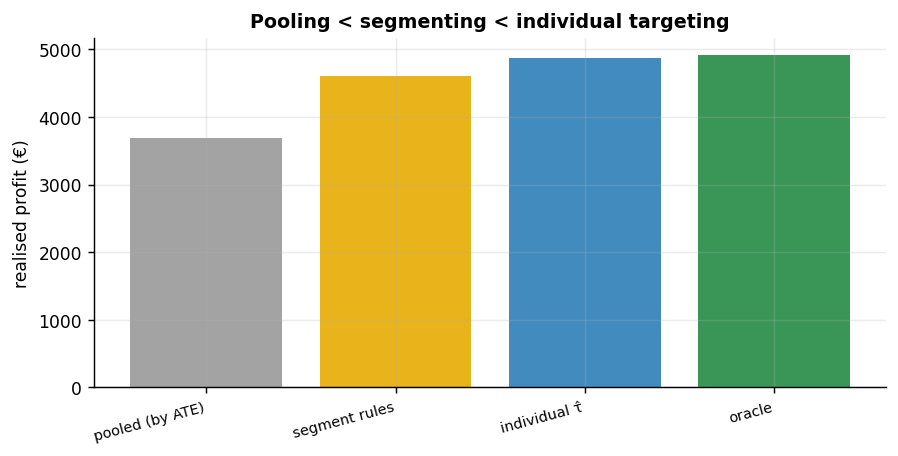

In [16]:
VALUE = 1.0
# segment decision table
rows = []
for name, c in [("low-value", cate_low), ("high-value", cate_high)]:
    d = c.draws(); p = (d > COST).mean()
    rows.append({"segment": name, "effect": round(d.mean(),2), "net_of_cost": round(d.mean()-COST,2),
                 "P(effect>cost)": round(p,2), "action": "SEND" if p>0.8 else ("SKIP" if p<0.5 else "TEST")})
tbl = pd.DataFrame(rows); print(tbl.to_string(index=False))

# four policies on the known per-customer truth: pooled < segmented < individual < oracle
gain = df.tau.values - COST
pooled_mask = np.full(len(df), ate.mean() > COST)                                  # treat-all-or-none on ATE
segmented_mask = np.where(df.is_high.values==1, cate_high.mean() > COST, cate_low.mean() > COST)
individual_mask = tau_hat > COST                                                    # per-customer τ̂ rule
oracle_mask = gain > 0
prof = {name: (mask * gain).sum() for name, mask in
        [("pooled (by ATE)", pooled_mask), ("segment rules", segmented_mask),
         ("individual τ̂", individual_mask), ("oracle", oracle_mask)]}
fig, ax = plt.subplots(figsize=(7, 3.6))
ax.bar(list(prof.keys()), list(prof.values()), color=[plots.GREY, plots.GOLD, plots.BLUE, plots.GREEN], alpha=0.9)
ax.set_ylabel("realised profit (€)"); ax.set_title("Pooling < segmenting < individual targeting")
plt.setp(ax.get_xticklabels(), rotation=15, ha="right", fontsize=8); fig.tight_layout()
print("\nRealised profit by policy:")
for k, v in prof.items(): print(f"  {k:18s} €{v:,.0f}")
print(f"\nMoving from pooled to individual targeting is worth €{prof['individual τ̂']-prof['pooled (by ATE)']:,.0f} "
      f"({(prof['individual τ̂']-prof['pooled (by ATE)'])/max(prof['pooled (by ATE)'],1):.0%} uplift).")

# --- Uncertainty on the headline: recompute the policy ladder per posterior draw --------------
# Each draw s implies tau^(s)(x) = b_e + b_ev*v + b_eg*g, hence its own rules and its own profit.
tau_draws = be[:, None] + bev[:, None] * df.is_high.values[None, :] + beg[:, None] * df.engagement.values[None, :]
ate_draws, hi_draws, lo_draws = ate.draws(), cate_high.draws(), cate_low.draws()
gain_hi_tot, gain_lo_tot = gain[df.is_high.values == 1].sum(), gain[df.is_high.values == 0].sum()
prof_pooled_d = np.where(ate_draws > COST, gain.sum(), 0.0)              # all-or-nothing, per draw
prof_seg_d = np.where(hi_draws > COST, gain_hi_tot, 0.0) + np.where(lo_draws > COST, gain_lo_tot, 0.0)
prof_ind_d = ((tau_draws > COST) * gain[None, :]).sum(axis=1)
inc_ind = prof_ind_d - prof_pooled_d                    # value of individual targeting vs pooling, per draw
inc_lo94, inc_hi94 = hdi94(inc_ind)
SCALE = 100_000 / len(df)                               # scale the n=1,500 sample to a 100k-customer base
print(f"\nValue of targeting vs pooling, per posterior draw (not just the plug-in point):")
print(f"  individual vs pooled: €{inc_ind.mean():,.0f}   94% HDI [€{inc_lo94:,.0f}, €{inc_hi94:,.0f}]   "
      f"P(>0) = {(inc_ind > 0).mean():.3f}")
print(f"  segment    vs pooled: €{(prof_seg_d - prof_pooled_d).mean():,.0f} on average — lumpier across draws,")
print(f"      because a discrete per-segment rule only changes when a segment posterior crosses the cost line")
print(f"  scaled to a 100k-customer base: individual targeting is worth ≈ €{inc_ind.mean() * SCALE:,.0f} "
      f"[€{inc_lo94 * SCALE:,.0f}, €{inc_hi94 * SCALE:,.0f}] per campaign")

Break-even engagement (where CATE = €8), per segment:
  low-value : g* = 0.53  (true 0.625)   94% HDI [0.46, 0.61]
              → SEND to low-value customers only ABOVE engagement ≈0.53
  high-value: g* = -0.28 (< 0) → high-value clear €8 at EVERY engagement level (always SEND)

Cost sweep €5–€12: the segment rule drops low-value once cost passes its CATE (€7.7), but the
pooled rule treats EVERYONE up to the ATE (€10.8) then flips to treat-NOBODY — surrendering all the
high-value profit above €10.8, exactly where segment and individual targeting keep earning.


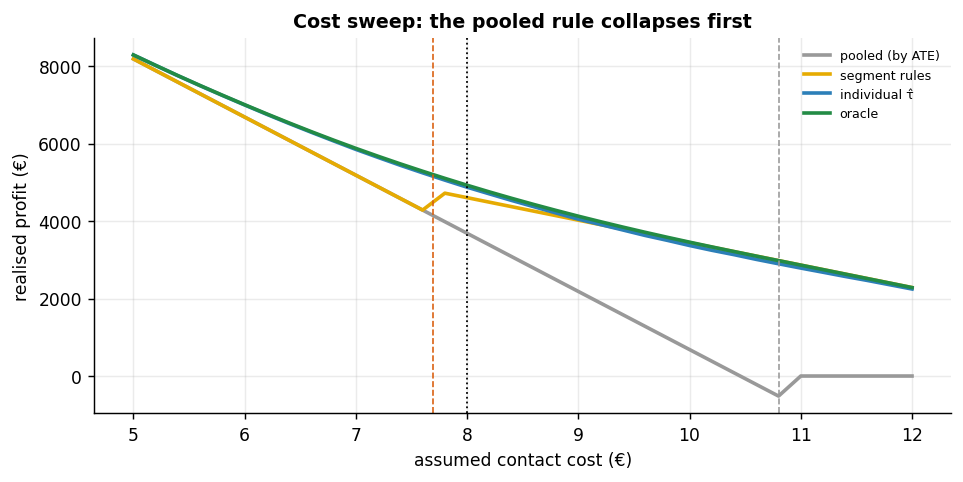

In [17]:
# (hdi94 — defined in the §5b cell — is reused here on DERIVED ratio draws, a quantity no pathmc
# result object carries; that is why the helper is notebook-local rather than an EstimandResult.hdi call.)
# --- Break-even engagement: the send rule, with uncertainty ------------------
# The email effect is CATE = be + bev*is_high + beg*engagement; solve CATE = COST for engagement.
g_low  = (COST - be) / beg                      # low-value  (is_high=0), per posterior draw
g_high = (COST - be - bev) / beg                # high-value (is_high=1)
hdi_low = hdi94(g_low)
print(f"Break-even engagement (where CATE = €{COST:.0f}), per segment:")
print(f"  low-value : g* = {g_low.mean():.2f}  (true 0.625)   94% HDI [{hdi_low[0]:.2f}, {hdi_low[1]:.2f}]")
print(f"              → SEND to low-value customers only ABOVE engagement ≈{g_low.mean():.2f}")
print(f"  high-value: g* = {g_high.mean():.2f} (< 0) → high-value clear €{COST:.0f} at EVERY engagement level (always SEND)")

# --- Cost sweep: where the policy decisions flip -----------------------------
costs = np.linspace(5, 12, 36); tau = df.tau.values
curves = {k: [] for k in ["pooled (by ATE)", "segment rules", "individual τ̂", "oracle"]}
for c in costs:
    gain_c = tau - c
    masks = {"pooled (by ATE)": np.full(len(df), ate.mean() > c),
             "segment rules": np.where(df.is_high.values == 1, cate_high.mean() > c, cate_low.mean() > c),
             "individual τ̂": tau_hat > c, "oracle": gain_c > 0}
    for k, mk in masks.items(): curves[k].append(float((mk * gain_c).sum()))
fig, ax = plt.subplots(figsize=(7.5, 3.8))
for k, col in [("pooled (by ATE)", plots.GREY), ("segment rules", plots.GOLD),
               ("individual τ̂", plots.BLUE), ("oracle", plots.GREEN)]:
    ax.plot(costs, curves[k], color=col, lw=2, label=k)
ax.axvline(COST, color="k", ls=":", lw=1); ax.axvline(cate_low.mean(), color=plots.ORANGE, ls="--", lw=0.9)
ax.axvline(ate.mean(), color=plots.GREY, ls="--", lw=0.9)
ax.set_xlabel("assumed contact cost (€)"); ax.set_ylabel("realised profit (€)")
ax.set_title("Cost sweep: the pooled rule collapses first"); ax.legend(frameon=False, fontsize=7); fig.tight_layout()
print(f"\nCost sweep €5–€12: the segment rule drops low-value once cost passes its CATE (€{cate_low.mean():.1f}), "
      f"but the\npooled rule treats EVERYONE up to the ATE (€{ate.mean():.1f}) then flips to treat-NOBODY — surrendering "
      f"all the\nhigh-value profit above €{ate.mean():.1f}, exactly where segment and individual targeting keep earning.")

**How to read the cost sweep.** The four policies earn nearly identical profit only at very low cost, where
"email everyone" is optimal. As the contact cost rises they **peel apart at their decision thresholds**: the
segment rule stops mailing low-value customers once cost crosses that segment's CATE (€7.7, orange), while the
**pooled rule keeps mailing everyone until cost passes the *pooled* ATE (€10.8, grey) — then collapses to
mailing no-one**, forfeiting the high-value profit that individual and segment targeting still capture. That
brittleness is the cost of one-size-fits-all: a single averaged decision has no way to keep the profitable
segment once the *average* stops clearing cost.

**The break-even engagement** turns the same €8 logic into an operational cutoff: this sample's fitted
low-value line crosses €8 at engagement **≈0.53** (94% HDI [0.46, 0.61]) — *mail a low-value customer only
once they are more engaged than that.* The true crossing is 0.625; the fitted cutoff sits a touch lower
because this sample's low-value CATE runs ~€0.7 high (the small solid-vs-dashed gap in the moderation panel),
and a break-even — a **ratio** of two estimated coefficients — amplifies that error near the crossing. That
is exactly why you carry the interval, not the point, into the decision — with eyes open: in this very sample even the 94% HDI misses the true 0.625 (ratio break-evens inherit *amplified* uncertainty near a crossing), while §5b's fresh-sample refits show the underlying CATEs are centred — and §5b's g* line now measures the ratio itself (bias and 94%-HDI coverage across seeds, printed there). So read the printed band as an honest *starting* range for a cutoff you would confirm on a holdout, not as a guarantee.

### 6b · The one-paragraph decision

> **To the CMO.** The email's effect is genuinely different across the base — the value-tier gap
> ($\beta_3 \approx$ €8) is real with near-certainty, and responsiveness climbs with engagement — so a
> one-size-fits-all send provably leaves money on the table. **High-value customers: always send.** Their
> effect clears the €8 contact cost at every engagement level, with $P(\text{effect}>\text{cost})$
> effectively 1. **Low-value customers: send only above the break-even engagement** printed in Step 6
> (≈ 0.5 on this sample, with a 94% band of roughly ±0.1) — and confirm that cutoff on a holdout before
> hard-coding it, because a ratio break-even is the fragile estimand of this analysis (§5b measured it;
> Step 6's read-out explains it). Moving from a blanket policy to per-customer targeting is worth on the
> order of €1.2k on this 1,500-customer base — ≈ €80k per 100k customers — and that value is sign-certain
> across the posterior (the printed HDI). Where we are *not* sure — the low-value, mid-engagement region —
> the next action is a properly sized A/B test (§5c prints the required n), not a rollout. **Act where
> we're sure; measure where we're not.**

The same decision, machine-readable — every number computed from this run, none typed by hand:

In [18]:
decision = {
    "segment_cate_low_eur": round(float(cate_low.mean()), 2),
    "segment_cate_low_hdi90": [round(float(v), 2) for v in cate_low.hdi(prob=0.90)],
    "segment_cate_high_eur": round(float(cate_high.mean()), 2),
    "segment_cate_high_hdi90": [round(float(v), 2) for v in cate_high.hdi(prob=0.90)],
    "gap_b_ev_eur": round(float(b_ev.mean()), 2),
    "P_gap_gt_0": round(float(p_gap), 4),
    "break_even_engagement_low": round(float(g_low.mean()), 3),
    "break_even_hdi94": [round(float(hdi_low[0]), 3), round(float(hdi_low[1]), 3)],
    "profit_pooled_eur": round(float(prof["pooled (by ATE)"]), 0),
    "profit_segment_rules_eur": round(float(prof["segment rules"]), 0),
    "profit_individual_eur": round(float(prof["individual τ̂"]), 0),
    "profit_oracle_eur": round(float(prof["oracle"]), 0),
    "value_individual_vs_pooled_eur": round(float(inc_ind.mean()), 0),
    "value_individual_vs_pooled_hdi94": [round(float(inc_lo94), 0), round(float(inc_hi94), 0)],
    "P_value_gt_0": round(float((inc_ind > 0).mean()), 4),
    "value_per_100k_customers_eur": round(float(inc_ind.mean() * SCALE), 0),
    "followup_test_n_low_segment": int(n_decisive),
    "ppc_coverage_5_95": round(float(ppc_cov), 3),
    "noise_segments_flagged": f"{int(false_hits.sum())}/{K}",
    "dag_implications_violated": f"{imp.n_violations}/{imp.n_tests}",
}
print(json.dumps(decision, indent=2, ensure_ascii=False))

{
  "segment_cate_low_eur": 7.69,
  "segment_cate_low_hdi90": [
    7.04,
    8.32
  ],
  "segment_cate_high_eur": 15.82,
  "segment_cate_high_hdi90": [
    15.0,
    16.61
  ],
  "gap_b_ev_eur": 8.13,
  "P_gap_gt_0": 1.0,
  "break_even_engagement_low": 0.531,
  "break_even_hdi94": [
    0.457,
    0.606
  ],
  "profit_pooled_eur": 3682.0,
  "profit_segment_rules_eur": 4602.0,
  "profit_individual_eur": 4873.0,
  "profit_oracle_eur": 4923.0,
  "value_individual_vs_pooled_eur": 1184.0,
  "value_individual_vs_pooled_hdi94": [
    1104.0,
    1241.0
  ],
  "P_value_gt_0": 1.0,
  "value_per_100k_customers_eur": 78915.0,
  "followup_test_n_low_segment": 6450,
  "ppc_coverage_5_95": 0.904,
  "noise_segments_flagged": "1/20",
  "dag_implications_violated": "0/6"
}


## 7 · Caveats

- **Heterogeneity is only as good as the moderator you measured.** If the real driver of
  differential response isn't `is_high`/`engagement` (or a proxy), the interaction won't catch it.
- **Slice enough ways and something will "respond".** §5c manufactured a "significant" segment out of
  pure noise on this very dataset. Pre-register the segments you'll act on, report posterior
  probabilities rather than significance stars, and shrink many-segment estimates with partial
  pooling (nb03).
- **The functional form is an assumption no DAG test can check.** §5d's omitted moderation sailed through
  the graph-falsification test while breaking every individual-level deliverable; on real data, pair the
  structural model with a PPC and a flexible cross-check.
- **Interaction ≠ causing the moderator.** We're not claiming *making* someone high-value changes
  responsiveness — only that responsiveness *differs* across pre-existing segments.
- **Random slopes for many thin segments.** With dozens of small segments, replace the single
  interaction with partially-pooled random slopes so noisy segments borrow strength (see nb 03).
- **Same unconfoundedness caveat** — here email is randomized; observationally a hidden common
  cause of email and spend would bias every segment effect (see nb 05).
